In [ ]:
!pip install -q transformers==5.16.1 datasets accelerate pandas psutil

In [ ]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

PyTorch: 2.11.0+cu128
Transformers: 5.16.1
device: cuda


In [ ]:
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "openai-community/gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(MODEL_ID)

model.to(device)
model.eval()

model.config.use_cache = False

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
print(len(model.transformer.h))

12


In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

print(dataset)

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

wikitext-2-raw-v1/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [ ]:
train_text = "\n\n".join(dataset["train"]["text"])
validation_text = "\n\n".join(dataset["validation"]["text"])
test_text = "\n\n".join(dataset["test"]["text"])

In [ ]:
import math

def calculate_ppl(model, text, block_size=512, max_tokens=50000):
    model.eval()

    ids = tokenizer(
        text,
        return_tensors="pt",
        add_special_tokens=False
    )["input_ids"][0]

    if max_tokens is not None:
        ids = ids[:max_tokens]

    n_blocks = len(ids) // block_size

    total_nll = 0.0
    total_tokens = 0

    with torch.no_grad():
        for i in range(n_blocks):
            x = ids[
                i * block_size :
                (i + 1) * block_size
            ].unsqueeze(0).to(device)

            outputs = model(
                input_ids=x,
                labels=x,
                use_cache=False
            )

            count = x.numel() - 1

            total_nll += outputs.loss.item() * count
            total_tokens += count

    return math.exp(total_nll / total_tokens)

In [ ]:
baseline_ppl = calculate_ppl(
    model,
    validation_text
)

print("Original GPT-2 PPL:", baseline_ppl)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (251048 > 1024). Running this sequence through the model will result in indexing errors
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Original GPT-2 PPL: 33.93831960527976


In [ ]:
from torch import nn
from transformers import AutoModelForCausalLM

def load_fresh_model():
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID)
    model.config.use_cache = False
    return model

def remove_layer(L):

    model = load_fresh_model()

    blocks = list(model.transformer.h)

    blocks = (
        blocks[:L]
        + blocks[L+1:]
    )

    model.transformer.h = nn.ModuleList(blocks)

    model.config.n_layer = len(blocks)

    return model

In [ ]:
remove_model = remove_layer(5)
remove_model.to(device)

print(len(remove_model.transformer.h))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

11


In [ ]:
remove_ppl = calculate_ppl(
    remove_model,
    validation_text
)

print(remove_ppl)

40.873501103364404


In [ ]:
import copy

def weighted_average_layer(L, alpha=0.5):

    model = load_fresh_model()

    block1 = model.transformer.h[L]
    block2 = model.transformer.h[L+1]

    merged = copy.deepcopy(block2)

    p1 = dict(block1.named_parameters())
    p2 = dict(block2.named_parameters())

    with torch.no_grad():

        for name, p in merged.named_parameters():

            p.copy_(
                alpha * p1[name]
                +
                (1 - alpha) * p2[name]
            )

    blocks = list(model.transformer.h)

    new_blocks = (
        blocks[:L]
        + [merged]
        + blocks[L+2:]
    )

    model.transformer.h = nn.ModuleList(new_blocks)

    model.config.n_layer = len(new_blocks)

    return model

In [ ]:
average_model = weighted_average_layer(
    L=5,
    alpha=0.5
)

average_model.to(device)

average_ppl = calculate_ppl(
    average_model,
    validation_text
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [ ]:
alpha = random.random()

random_model = weighted_average_layer(
    L=5,
    alpha=alpha
)

print("alpha =", alpha)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

alpha = 0.6394267984578837


In [ ]:
def collect_hidden_states(
    model,
    text,
    L,
    total_tokens=4096,
    chunk_size=256
):

    ids = tokenizer(
        text,
        return_tensors="pt",
        add_special_tokens=False
    )["input_ids"][0]

    ids = ids[:total_tokens]

    X_list = []
    Y1_list = []
    Y2_list = []

    model.eval()

    with torch.no_grad():

        for start in range(
            0,
            len(ids) - chunk_size + 1,
            chunk_size
        ):

            x = ids[
                start:start+chunk_size
            ].unsqueeze(0).to(device)

            outputs = model(
                input_ids=x,
                output_hidden_states=True,
                use_cache=False
            )

            h = outputs.hidden_states

            # h[0] = embeddings
            # h[L] = input to Block L
            # h[L+1] = output of Block L
            # h[L+2] = output of Block L+1

            X = h[L]
            Y1 = h[L+1]
            Y2 = h[L+2]

            X_list.append(
                X.reshape(-1, X.shape[-1]).cpu().float()
            )

            Y1_list.append(
                Y1.reshape(-1, Y1.shape[-1]).cpu().float()
            )

            Y2_list.append(
                Y2.reshape(-1, Y2.shape[-1]).cpu().float()
            )

    return (
        torch.cat(X_list),
        torch.cat(Y1_list),
        torch.cat(Y2_list)
    )

In [ ]:
original_model = load_fresh_model().to(device)

X, Y1, Y2 = collect_hidden_states(
    original_model,
    train_text,
    L=5
)

print(X.shape)
print(Y1.shape)
print(Y2.shape)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

torch.Size([4096, 768])
torch.Size([4096, 768])
torch.Size([4096, 768])


In [ ]:
def fit_affine(X, Y, ridge=1e-4):

    n, d = X.shape

    ones = torch.ones(
        n,
        1,
        dtype=X.dtype
    )

    X_aug = torch.cat(
        [X, ones],
        dim=1
    )

    I = torch.eye(
        d + 1,
        dtype=X.dtype
    )

    # biasにはregularizationをかけない
    I[-1, -1] = 0

    solution = torch.linalg.solve(
        X_aug.T @ X_aug + ridge * I,
        X_aug.T @ Y
    )

    A = solution[:-1]
    b = solution[-1]

    return A, b

In [ ]:
A1, b1 = fit_affine(X, Y1)
A2, b2 = fit_affine(Y1, Y2)

In [ ]:
A_remove = A2
b_remove = b2

In [ ]:
A_avg = 0.5 * A1 + 0.5 * A2
b_avg = 0.5 * b1 + 0.5 * b2

In [ ]:
alpha = 0.3

A_random = (
    alpha * A1
    +
    (1-alpha) * A2
)

b_random = (
    alpha * b1
    +
    (1-alpha) * b2
)

In [ ]:
A_mul = A1 @ A2

In [ ]:
b_mul = b1 @ A2 + b2

In [ ]:
class AffineMergedBlock(nn.Module):

    def __init__(self, A, b):
        super().__init__()

        d = A.shape[0]

        self.linear = nn.Linear(d, d)

        with torch.no_grad():

            # nn.Linearは x @ W.T + b
            self.linear.weight.copy_(A.T)

            self.linear.bias.copy_(b)

    def forward(
        self,
        hidden_states,
        *args,
        **kwargs
    ):
        return self.linear(hidden_states)

In [ ]:
def build_linear_merged_model(
    L,
    A,
    b
):

    model = load_fresh_model()

    merged = AffineMergedBlock(
        A,
        b
    )

    blocks = list(
        model.transformer.h
    )

    new_blocks = (
        blocks[:L]
        + [merged]
        + blocks[L+2:]
    )

    model.transformer.h = nn.ModuleList(
        new_blocks
    )

    model.config.n_layer = len(
        new_blocks
    )

    model.config.use_cache = False

    return model

In [ ]:
multiply_model = build_linear_merged_model(
    L=5,
    A=A_mul,
    b=b_mul
)

multiply_model.to(device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-4): 5 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
      (5): AffineMergedBlock(
        (linear): Linear(in_features=768, out_features=768, bias=True)
      )
      (6-10): 5 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=

In [ ]:
multiply_ppl = calculate_ppl(
    multiply_model,
    validation_text
)

print("Multiply PPL:", multiply_ppl)

Multiply PPL: 53.317195416240565


In [ ]:
def parameter_count(model):

    return sum(
        p.numel()
        for p in model.parameters()
    )

In [ ]:
print(
    parameter_count(original_model)
)

print(
    parameter_count(multiply_model)
)

124439808
110854656


In [ ]:
import time

def measure_latency(
    model,
    text,
    seq_len=256,
    repeat=30
):

    ids = tokenizer(
        text,
        return_tensors="pt",
        add_special_tokens=False
    )["input_ids"][:, :seq_len].to(device)

    model.eval()

    # warm-up
    with torch.no_grad():
        for _ in range(5):
            model(
                ids,
                use_cache=False
            )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():
        for _ in range(repeat):

            model(
                ids,
                use_cache=False
            )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end = time.perf_counter()

    return (
        (end-start)
        / repeat
        * 1000
    )

device: cuda
mode: quick
pairs: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11)]
direct sweep: True
DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Number of Transformer blocks: 12
Hidden size: 768

===== ORIGINAL GPT-2 =====
Validation PPL : 29.653508547265364
Parameters     : 124,439,808
Latency (ms)   : 21.872130200017637

===== LINEAR SANITY CHECK =====
{'max_abs_error': 1.52587890625e-05, 'mse': 4.92083760891826e-12}

AFFINE PAIR 1/11: 0-1

[Affine] pair 0-1


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

,Pair_Start,Pair,Method,PPL_mean,PPL_std,Alpha_mean,Parameters,Latency_ms_mean,Parameter_Reduction_%
0,0,0-1,Average,4065.671323,0.000000,0.5,117351936,20.613448,5.695824
2,0,0-1,Remove,6328.507553,0.000000,NaN,117351936,20.984466,5.695824
1,0,0-1,Random-Weight Average,7544.339085,3467.314903,NaN,117351936,20.534622,5.695824
5,1,1-2,Remove,30.945605,0.000000,NaN,117351936,20.817415,5.695824
3,1,1-2,Average,166.245604,0.000000,0.5,117351936,21.328744,5.695824
4,1,1-2,Random-Weight Average,288.851958,149.777237,NaN,117351936,20.517672,5.695824
8,2,2-3,Remove,33.588035,0.000000,NaN,117351936,20.332205,5.695824
6,2,2-3,Average,143.196974,0.000000,0.5,117351936,20.901800,5.695824
7,2,2-3,Random-Weight Average,205.731700,28.084562,NaN,117351936,20.588289,5.695824
11,3,3-4,Remove,33.578615,0.000000,NaN,117351936,20.727395,5.695824



===== PPL PIVOT TABLE =====


Method,Average,Multiply,Random-Weight Average,Remove
Pair,,,,
0-1,2974.605580,444.609337,5.300192e+03,3951.099399
1-2,54.456680,109.119865,5.175040e+04,60.701959
2-3,49.749361,68.525651,3.486081e+04,71.911124
3-4,48.188450,49.585042,1.528179e+06,52.492118
4-5,43.816421,44.069133,2.163777e+05,47.166442
5-6,44.843815,46.828949,3.160817e+04,49.339299
6-7,41.983506,45.432528,4.620774e+04,44.235164
7-8,43.175383,46.184442,5.324576e+03,46.120905
8-9,44.187067,49.437195,1.901293e+03,49.434698



===== HIDDEN MSE PIVOT TABLE =====


Method,Average,Multiply,Random-Weight Average,Remove
Pair,,,,
0-1,3.969232,0.818568,7.774230,9.517459
1-2,24.599081,0.841011,30.985257,22.032761
2-3,6.030556,0.865309,32.642972,18.558510
3-4,0.884701,0.888144,34.325258,1.052032
4-5,0.963117,1.038932,29.210145,1.103742
5-6,1.233777,1.363519,34.700418,1.377043
6-7,1.851786,2.024831,35.906804,2.012373
7-8,2.841825,3.087601,34.875279,3.079325
8-9,4.906084,5.313062,50.036315,5.101606


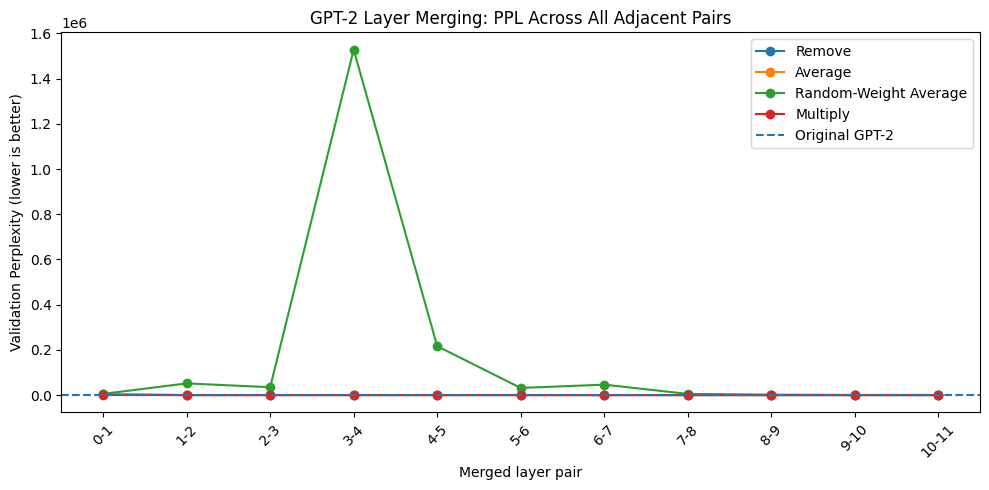

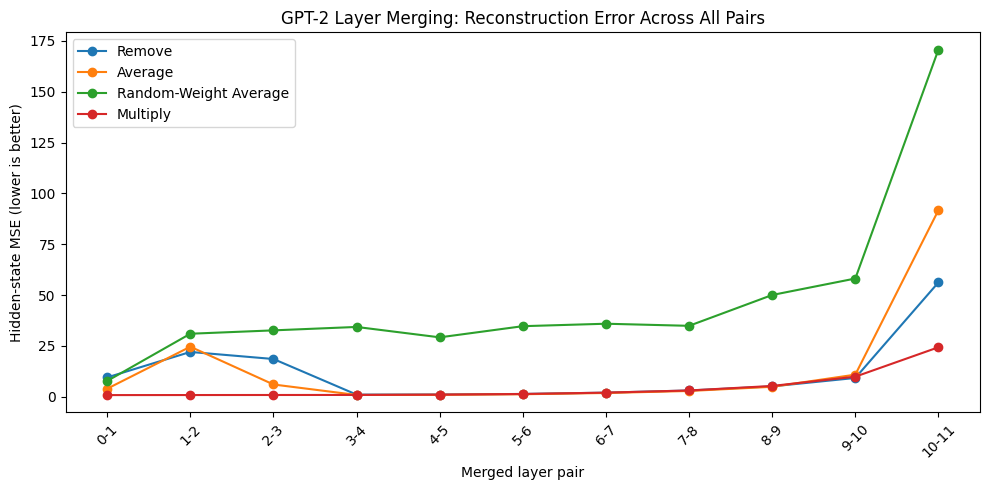

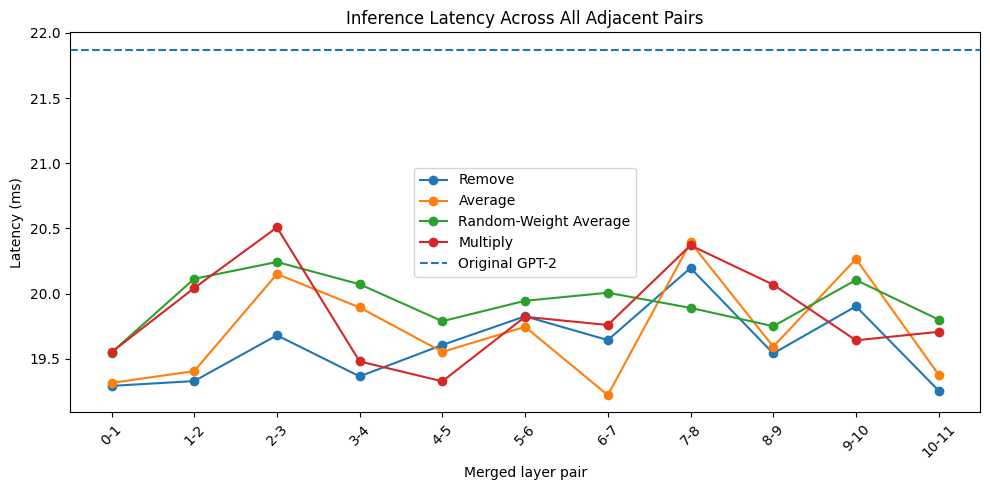


===== MULTIPLY VS AVERAGE =====


,Pair,Average_PPL,Multiply_PPL,Multiply_minus_Average_PPL,Multiply_Better,Average_MSE,Multiply_MSE
0,0-1,2974.605580,444.609337,-2529.996243,True,3.969232,0.818568
1,1-2,54.456680,109.119865,54.663186,False,24.599081,0.841011
2,2-3,49.749361,68.525651,18.776290,False,6.030556,0.865309
3,3-4,48.188450,49.585042,1.396593,False,0.884701,0.888144
4,4-5,43.816421,44.069133,0.252712,False,0.963117,1.038932
5,5-6,44.843815,46.828949,1.985134,False,1.233777,1.363519
6,6-7,41.983506,45.432528,3.449021,False,1.851786,2.024831
7,7-8,43.175383,46.184442,3.009059,False,2.841825,3.087601
8,8-9,44.187067,49.437195,5.250128,False,4.906084,5.313062
9,9-10,48.610601,57.946677,9.336076,False,10.873215,9.873056



Multiply beats Average on 2/11 adjacent layer pairs.

Selected by validation:
Pair: 6-7
Method: Average

Original GPT-2 Test PPL: 39.57862550958222


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


===== FINAL SELECTED TEST RESULT =====
Original Test PPL: 39.57862550958222
Compressed pair: 6-7
Method: Average
Random seed: None
Compressed Test PPL: 54.5554401420365
Parameters: 110854656
Parameter reduction (%): 10.917046737969894
Latency (ms): 19.297113600009652

===== SAVED FILES =====
/content/affine_all_pairs_raw.csv
/content/affine_all_pairs_summary.csv
/content/best_method_per_pair.csv
/content/multiply_vs_average.csv
/content/direct_all_pairs_raw.csv
/content/direct_all_pairs_summary.csv

===== AUTOMATIC INTERPRETATION =====
Original validation PPL: 29.6535
Multiply beat Average on 2/11 pairs.

Best Average:
Pair = 6-7 , PPL = 41.9835

Best Multiply:
Pair = 4-5 , PPL = 44.0691

Best compressed validation configuration:
Pair = 6-7 , Method = Average , PPL = 41.9835


In [ ]:
import gc
import math
import random
import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


# ============================================================
# 0. CONFIGURATION
# ============================================================

MODEL_ID = "openai-community/gpt2"
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Experiment size
# ------------------------------------------------------------
# "quick":
#   all 11 adjacent pairs, but fewer fit/eval tokens and 3 random runs
#
# "full":
#   all 11 adjacent pairs, more tokens and 5 random runs
#
# Start with "quick". If everything works, switch to "full".
MODE = "quick"

if MODE == "quick":
    FIT_TOKENS = 4096
    EVAL_TOKENS = 10000
    RANDOM_RUNS = 3
    LATENCY_REPEATS = 10
else:
    FIT_TOKENS = 20000
    EVAL_TOKENS = 50000
    RANDOM_RUNS = 5
    LATENCY_REPEATS = 30

EVAL_BLOCK_SIZE = 512
STATE_CHUNK_SIZE = 256
RIDGE = 1e-4

# ============================================================
# IMPORTANT:
# Test every adjacent pair of GPT-2's 12 Transformer blocks.
#
# 0 -> pair (0,1)
# 1 -> pair (1,2)
# ...
# 10 -> pair (10,11)
# ============================================================

PAIR_STARTS = list(range(11))

# Direct GPT-2 baselines are useful, but expensive because each
# pair is evaluated with several real Transformer-block variants.
RUN_DIRECT_SWEEP = True

# Final test set:
# By default, select the best pair/method using VALIDATION,
# then evaluate only that choice on TEST.
#
# Set True only if you explicitly want a full test-set table
# for every pair/method after all decisions are already fixed.
TEST_ALL_PAIRS = False

print("device:", DEVICE)
print("mode:", MODE)
print("pairs:", [(L, L + 1) for L in PAIR_STARTS])
print("direct sweep:", RUN_DIRECT_SWEEP)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()


# ============================================================
# 2. DATASET: WIKITEXT-2
# ============================================================

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

def join_nonempty(split):
    return "\n\n".join(
        x for x in split["text"]
        if x is not None and x.strip()
    )

train_text = join_nonempty(dataset["train"])
validation_text = join_nonempty(dataset["validation"])
test_text = join_nonempty(dataset["test"])

print(dataset)


# ============================================================
# 3. GPT-2
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# We manually split the token sequence into small blocks.
# This suppresses an unnecessary tokenizer max-length warning.
tokenizer.model_max_length = int(1e12)

def load_fresh_model():
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID)
    model.config.use_cache = False
    model.eval()
    return model

original_model = load_fresh_model().to(DEVICE)

print("Number of Transformer blocks:", len(original_model.transformer.h))
print("Hidden size:", original_model.config.n_embd)


# ============================================================
# 4. COMMON METRICS
# ============================================================

@torch.no_grad()
def calculate_ppl(
    model,
    text,
    block_size=EVAL_BLOCK_SIZE,
    max_tokens=EVAL_TOKENS
):
    """
    Approximate perplexity using the same non-overlapping chunks
    for every model.

    Lower PPL = better language-model quality.
    """
    model.eval()

    ids = tokenizer(
        text,
        return_tensors="pt",
        add_special_tokens=False
    )["input_ids"][0]

    if max_tokens is not None:
        ids = ids[:max_tokens]

    n_blocks = len(ids) // block_size

    if n_blocks == 0:
        raise ValueError("Not enough tokens for one evaluation block.")

    total_nll = 0.0
    total_pred_tokens = 0

    for i in range(n_blocks):
        x = ids[
            i * block_size:
            (i + 1) * block_size
        ].unsqueeze(0).to(DEVICE)

        outputs = model(
            input_ids=x,
            labels=x,
            use_cache=False
        )

        count = x.numel() - 1
        total_nll += outputs.loss.item() * count
        total_pred_tokens += count

    return math.exp(total_nll / total_pred_tokens)


def parameter_count(model):
    return sum(p.numel() for p in model.parameters())


@torch.no_grad()
def measure_latency(
    model,
    text,
    seq_len=256,
    repeats=LATENCY_REPEATS
):
    """
    Forward-pass latency in milliseconds.
    Use the same GPU, sequence length, and repeats for every model.
    """
    model.eval()

    ids = tokenizer(
        text,
        return_tensors="pt",
        add_special_tokens=False
    )["input_ids"][:, :seq_len].to(DEVICE)

    # Warm-up
    for _ in range(5):
        _ = model(ids, use_cache=False)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    for _ in range(repeats):
        _ = model(ids, use_cache=False)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end = time.perf_counter()

    return 1000.0 * (end - start) / repeats


def free_model(model):
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 5. ORIGINAL GPT-2 BASELINE
# ============================================================

baseline_ppl = calculate_ppl(
    original_model,
    validation_text
)

baseline_params = parameter_count(
    original_model
)

baseline_latency = measure_latency(
    original_model,
    validation_text
)

print("\n===== ORIGINAL GPT-2 =====")
print("Validation PPL :", baseline_ppl)
print("Parameters     :", f"{baseline_params:,}")
print("Latency (ms)   :", baseline_latency)


# ============================================================
# 6. LINEAR SANITY CHECK
# ============================================================

def linear_sanity_check(seed=SEED):
    """
    In a purely linear network:

        (X @ W1) @ W2 = X @ (W1 @ W2)

    The error should be approximately zero.
    """
    torch.manual_seed(seed)

    d = 16
    n = 128

    X = torch.randn(n, d)
    W1 = torch.randn(d, d)
    W2 = torch.randn(d, d)

    sequential = (X @ W1) @ W2
    composed = X @ (W1 @ W2)

    return {
        "max_abs_error":
            (sequential - composed).abs().max().item(),

        "mse":
            torch.mean(
                (sequential - composed) ** 2
            ).item()
    }

sanity = linear_sanity_check()

print("\n===== LINEAR SANITY CHECK =====")
print(sanity)


# ============================================================
# 7. DIRECT GPT-2 BASELINES
#
# These implement assignment conditions 1-3 directly on
# actual GPT-2 Transformer blocks.
#
# 1. Remove L
# 2. Average L and L+1
# 3. Average L+1 with a random weight tensor drawn from the
#    same empirical distribution, then remove L
#
# A literal full-block matrix multiplication is not defined
# because GPT-2 blocks contain attention, LayerNorm, residual
# connections, GELU, etc.
# ============================================================

def remove_real_block(L):
    model = load_fresh_model()

    blocks = list(model.transformer.h)
    new_blocks = (
        blocks[:L]
        + blocks[L + 1:]
    )

    model.transformer.h = nn.ModuleList(
        new_blocks
    )

    model.config.n_layer = len(
        new_blocks
    )

    return model


def average_real_blocks(
    L,
    alpha=0.5
):
    """
    Merge corresponding parameters:
        theta_merge =
            alpha * theta_L
            + (1-alpha) * theta_(L+1)
    """
    model = load_fresh_model()

    block1 = model.transformer.h[L]
    block2 = model.transformer.h[L + 1]

    merged = copy.deepcopy(block2)

    p1 = dict(
        block1.named_parameters()
    )

    p2 = dict(
        block2.named_parameters()
    )

    with torch.no_grad():

        for name, p in merged.named_parameters():

            if (
                name not in p1
                or name not in p2
            ):
                raise KeyError(
                    f"{name} is missing"
                )

            if p1[name].shape != p2[name].shape:
                raise ValueError(
                    f"Shape mismatch for {name}"
                )

            p.copy_(
                alpha * p1[name]
                + (1.0 - alpha) * p2[name]
            )

    blocks = list(
        model.transformer.h
    )

    new_blocks = (
        blocks[:L]
        + [merged]
        + blocks[L + 2:]
    )

    model.transformer.h = nn.ModuleList(
        new_blocks
    )

    model.config.n_layer = len(
        new_blocks
    )

    return model


def shuffle_same_distribution(
    tensor,
    generator
):
    """
    Create a random tensor with exactly the same empirical
    distribution as `tensor` by randomly permuting its entries.

    This preserves:
      - shape
      - all original values
      - mean
      - standard deviation
      - histogram / empirical distribution

    Only the positions of the values are randomized.
    """
    shape = tensor.shape
    flat = tensor.detach().cpu().reshape(-1)

    perm = torch.randperm(
        flat.numel(),
        generator=generator
    )

    shuffled = flat[perm].reshape(shape)

    return shuffled.to(
        device=tensor.device,
        dtype=tensor.dtype
    )


def random_weight_average_real_block(
    L,
    seed
):
    """
    Condition 3:

      1. Take block L+1.
      2. For every parameter tensor of block L+1, create a random
         tensor by shuffling its entries. The random tensor therefore
         has exactly the same empirical distribution as the original
         parameter tensor.
      3. Average the original and random tensors 50/50.
      4. Remove block L.
      5. Keep the randomized-average version of block L+1.

    Thus:
        theta_random ~ same empirical distribution as theta_(L+1)
        theta_merge = 0.5 * theta_(L+1) + 0.5 * theta_random
    """
    model = load_fresh_model()

    blocks = list(
        model.transformer.h
    )

    block2 = blocks[L + 1]
    merged = copy.deepcopy(block2)

    p2 = dict(
        block2.named_parameters()
    )

    generator = torch.Generator(
        device="cpu"
    )
    generator.manual_seed(seed)

    with torch.no_grad():

        for name, p in merged.named_parameters():

            if name not in p2:
                raise KeyError(
                    f"{name} is missing"
                )

            original_parameter = p2[name]

            random_parameter = shuffle_same_distribution(
                original_parameter,
                generator
            )

            p.copy_(
                0.5 * original_parameter
                + 0.5 * random_parameter
            )

    # Remove L and replace L+1 by the randomized-average block.
    new_blocks = (
        blocks[:L]
        + [merged]
        + blocks[L + 2:]
    )

    model.transformer.h = nn.ModuleList(
        new_blocks
    )

    model.config.n_layer = len(
        new_blocks
    )

    return model


def evaluate_model(
    model,
    text
):
    model = model.to(DEVICE).eval()

    return {
        "PPL":
            calculate_ppl(
                model,
                text
            ),

        "Parameters":
            parameter_count(model),

        "Latency_ms":
            measure_latency(
                model,
                text
            ),
    }


def run_direct_pair(L):
    rows = []

    print(
        f"\n[Direct] pair {L}-{L+1}"
    )

    # ----------------------------
    # 1. Remove
    # ----------------------------
    m = remove_real_block(L)

    r = evaluate_model(
        m,
        validation_text
    )

    rows.append({
        "Family": "Direct GPT-2",
        "Pair_Start": L,
        "Pair": f"{L}-{L+1}",
        "Method": "Remove",
        "Run": np.nan,
        "Alpha": np.nan,
        "Random_Seed": np.nan,
        **r
    })

    free_model(m)

    # ----------------------------
    # 2. 50/50 Average
    # ----------------------------
    m = average_real_blocks(
        L,
        alpha=0.5
    )

    r = evaluate_model(
        m,
        validation_text
    )

    rows.append({
        "Family": "Direct GPT-2",
        "Pair_Start": L,
        "Pair": f"{L}-{L+1}",
        "Method": "Average",
        "Run": np.nan,
        "Alpha": 0.5,
        "Random_Seed": np.nan,
        **r
    })

    free_model(m)

    # ----------------------------
    # 3. Random-Weight Average
    # ----------------------------
    # Randomness is in the weight tensor itself, NOT in alpha.
    # Each random tensor is a shuffled version of the corresponding
    # L+1 parameter tensor, so the empirical distribution is identical.
    for run in range(RANDOM_RUNS):

        random_seed = (
            SEED
            + 1000 * L
            + run
        )

        m = random_weight_average_real_block(
            L,
            seed=random_seed
        )

        r = evaluate_model(
            m,
            validation_text
        )

        rows.append({
            "Family": "Direct GPT-2",
            "Pair_Start": L,
            "Pair": f"{L}-{L+1}",
            "Method": "Random-Weight Average",
            "Run": run,
            "Alpha": np.nan,
            "Random_Seed": random_seed,
            **r
        })

        free_model(m)

    return pd.DataFrame(rows)


# ============================================================
# 8. COLLECT REAL HIDDEN-STATE TRANSFORMATIONS
#
# X  = input to block L
# Y1 = output of block L
# Y2 = output of block L+1
# ============================================================

def _as_tensor(output):
    if isinstance(
        output,
        (tuple, list)
    ):
        return output[0]

    return output


@torch.no_grad()
def collect_pair_states(
    model,
    text,
    L,
    total_tokens=FIT_TOKENS,
    chunk_size=STATE_CHUNK_SIZE
):
    ids = tokenizer(
        text,
        return_tensors="pt",
        add_special_tokens=False
    )["input_ids"][0]

    ids = ids[:total_tokens]

    X_list = []
    Y1_list = []
    Y2_list = []

    d = model.config.n_embd

    def pre_hook_L(
        module,
        inputs
    ):
        h = inputs[0].detach()

        X_list.append(
            h.reshape(
                -1,
                d
            ).cpu().float()
        )

    def post_hook_L(
        module,
        inputs,
        output
    ):
        h = _as_tensor(
            output
        ).detach()

        Y1_list.append(
            h.reshape(
                -1,
                d
            ).cpu().float()
        )

    def post_hook_L1(
        module,
        inputs,
        output
    ):
        h = _as_tensor(
            output
        ).detach()

        Y2_list.append(
            h.reshape(
                -1,
                d
            ).cpu().float()
        )

    handles = [
        model.transformer.h[L]
        .register_forward_pre_hook(
            pre_hook_L
        ),

        model.transformer.h[L]
        .register_forward_hook(
            post_hook_L
        ),

        model.transformer.h[L + 1]
        .register_forward_hook(
            post_hook_L1
        ),
    ]

    try:

        for start in range(
            0,
            len(ids),
            chunk_size
        ):

            x = ids[
                start:
                start + chunk_size
            ]

            if x.numel() < 2:
                continue

            _ = model(
                x.unsqueeze(0).to(DEVICE),
                use_cache=False
            )

    finally:

        for h in handles:
            h.remove()

    X = torch.cat(
        X_list,
        dim=0
    )

    Y1 = torch.cat(
        Y1_list,
        dim=0
    )

    Y2 = torch.cat(
        Y2_list,
        dim=0
    )

    return X, Y1, Y2


# ============================================================
# 9. FIT EFFECTIVE AFFINE MAPS
#
# Row-vector convention:
#
#   Y ~= X @ A + b
# ============================================================

def fit_affine(
    X,
    Y,
    ridge=RIDGE
):
    """
    Ridge-fitted affine map.

    Uses centering so the bias can be handled separately.
    """

    X = X.double()
    Y = Y.double()

    x_mean = X.mean(
        dim=0,
        keepdim=True
    )

    y_mean = Y.mean(
        dim=0,
        keepdim=True
    )

    Xc = X - x_mean
    Yc = Y - y_mean

    gram = Xc.T @ Xc

    diag_scale = (
        gram.diag()
        .mean()
        .clamp_min(1e-12)
    )

    reg = (
        ridge
        * diag_scale
        * torch.eye(
            gram.shape[0],
            dtype=gram.dtype
        )
    )

    A = torch.linalg.solve(
        gram + reg,
        Xc.T @ Yc
    )

    b = (
        y_mean
        - x_mean @ A
    ).squeeze(0)

    return (
        A.float(),
        b.float()
    )


# ============================================================
# 10. FOUR FAIR AFFINE CONDITIONS
#
# All four methods are represented by exactly one
# 768 -> 768 affine transformation.
#
# Remove:
#   A_remove = A2
#
# Average:
#   A_avg = 0.5*A1 + 0.5*A2
#
# Random-Weight Average:
#   A_random has the same empirical distribution as A2
#   b_random has the same empirical distribution as b2
#
#   A_rand_avg = 0.5*A2 + 0.5*A_random
#   b_rand_avg = 0.5*b2 + 0.5*b_random
#
# Multiply:
#   (X A1 + b1) A2 + b2
#
# Therefore:
#   A_mul = A1 @ A2
#   b_mul = b1 @ A2 + b2
# ============================================================

def make_affine_conditions(
    A1,
    b1,
    A2,
    b2
):
    return {
        "Remove": (
            A2,
            b2
        ),

        "Average": (
            0.5 * A1
            + 0.5 * A2,

            0.5 * b1
            + 0.5 * b2
        ),

        "Multiply": (
            A1 @ A2,
            b1 @ A2 + b2
        ),
    }


def make_random_weight_affine_condition(
    A2,
    b2,
    seed
):
    """
    Affine version of condition 3.

    Random A/b are created by shuffling the entries of A2/b2.
    Therefore they have exactly the same empirical distributions
    as A2/b2, while destroying their learned coordinate structure.
    """
    generator = torch.Generator(
        device="cpu"
    )
    generator.manual_seed(seed)

    A_random = shuffle_same_distribution(
        A2,
        generator
    )

    b_random = shuffle_same_distribution(
        b2,
        generator
    )

    A_merge = (
        0.5 * A2
        + 0.5 * A_random
    )

    b_merge = (
        0.5 * b2
        + 0.5 * b_random
    )

    return A_merge, b_merge


# ============================================================
# 11. HIDDEN-STATE RECONSTRUCTION ERROR
# ============================================================

@torch.no_grad()
def hidden_mse(
    X,
    Y_target,
    A,
    b
):
    pred = X @ A + b

    return torch.mean(
        (pred - Y_target) ** 2
    ).item()


# ============================================================
# 12. AFFINE REPLACEMENT BLOCK
# ============================================================

class AffineMergedBlock(nn.Module):

    def __init__(
        self,
        A,
        b
    ):
        super().__init__()

        d = A.shape[0]

        self.linear = nn.Linear(
            d,
            d
        )

        with torch.no_grad():

            # nn.Linear:
            # x @ weight.T + bias
            self.linear.weight.copy_(
                A.T
            )

            self.linear.bias.copy_(
                b
            )

    def forward(
        self,
        hidden_states,
        *args,
        **kwargs
    ):
        return self.linear(
            hidden_states
        )


def build_affine_merged_model(
    L,
    A,
    b
):
    """
    Replace blocks L and L+1 by one affine block.
    """
    model = load_fresh_model()

    merged = AffineMergedBlock(
        A,
        b
    )

    blocks = list(
        model.transformer.h
    )

    new_blocks = (
        blocks[:L]
        + [merged]
        + blocks[L + 2:]
    )

    model.transformer.h = nn.ModuleList(
        new_blocks
    )

    model.config.n_layer = len(
        new_blocks
    )

    model.config.use_cache = False

    return model


# ============================================================
# 13. RUN THE FAIR FOUR-WAY EXPERIMENT FOR ONE PAIR
# ============================================================

def run_affine_pair(L):
    print(
        f"\n[Affine] pair {L}-{L+1}"
    )

    # --------------------------------------------------------
    # Fit A1/A2 on TRAIN only
    # --------------------------------------------------------
    X_train, Y1_train, Y2_train = collect_pair_states(
        original_model,
        train_text,
        L,
        total_tokens=FIT_TOKENS
    )

    A1, b1 = fit_affine(
        X_train,
        Y1_train
    )

    A2, b2 = fit_affine(
        Y1_train,
        Y2_train
    )

    # --------------------------------------------------------
    # Independent hidden-state evaluation on VALIDATION
    # --------------------------------------------------------
    X_val, Y1_val, Y2_val = collect_pair_states(
        original_model,
        validation_text,
        L,
        total_tokens=min(
            FIT_TOKENS,
            EVAL_TOKENS
        )
    )

    rows = []

    fixed_conditions = make_affine_conditions(
        A1,
        b1,
        A2,
        b2
    )

    # --------------------------------------------------------
    # Fixed methods:
    # Remove / Average / Multiply
    # --------------------------------------------------------
    for method in [
        "Remove",
        "Average",
        "Multiply"
    ]:

        A, b = fixed_conditions[
            method
        ]

        local_mse = hidden_mse(
            X_val,
            Y2_val,
            A,
            b
        )

        m = build_affine_merged_model(
            L,
            A,
            b
        ).to(DEVICE)

        rows.append({
            "Family":
                "Affine fair comparison",

            "Pair_Start":
                L,

            "Pair":
                f"{L}-{L+1}",

            "Method":
                method,

            "Run":
                np.nan,

            "Alpha":
                0.5
                if method == "Average"
                else np.nan,

            "Random_Seed":
                np.nan,

            "Hidden_MSE":
                local_mse,

            "PPL":
                calculate_ppl(
                    m,
                    validation_text
                ),

            "Parameters":
                parameter_count(m),

            "Latency_ms":
                measure_latency(
                    m,
                    validation_text
                ),
        })

        free_model(m)

    # --------------------------------------------------------
    # Random-Weight Average:
    # multiple reproducible shuffled-weight runs per pair
    # --------------------------------------------------------
    for run in range(
        RANDOM_RUNS
    ):

        random_seed = (
            SEED
            + 1000 * L
            + run
        )

        A, b = make_random_weight_affine_condition(
            A2,
            b2,
            seed=random_seed
        )

        local_mse = hidden_mse(
            X_val,
            Y2_val,
            A,
            b
        )

        m = build_affine_merged_model(
            L,
            A,
            b
        ).to(DEVICE)

        rows.append({
            "Family":
                "Affine fair comparison",

            "Pair_Start":
                L,

            "Pair":
                f"{L}-{L+1}",

            "Method":
                "Random-Weight Average",

            "Run":
                run,

            "Alpha":
                np.nan,

            "Random_Seed":
                random_seed,

            "Hidden_MSE":
                local_mse,

            "PPL":
                calculate_ppl(
                    m,
                    validation_text
                ),

            "Parameters":
                parameter_count(m),

            "Latency_ms":
                measure_latency(
                    m,
                    validation_text
                ),
        })

        free_model(m)

    fitted = {
        "A1": A1,
        "b1": b1,
        "A2": A2,
        "b2": b2
    }

    return (
        pd.DataFrame(rows),
        fitted
    )


# ============================================================
# 14. RUN ALL 11 ADJACENT PAIRS
# ============================================================

all_affine_results = []
all_fitted_maps = {}

for idx, L in enumerate(
    PAIR_STARTS,
    start=1
):
    print(
        "\n"
        + "=" * 70
    )

    print(
        f"AFFINE PAIR {idx}/{len(PAIR_STARTS)}: "
        f"{L}-{L+1}"
    )

    print(
        "=" * 70
    )

    df_pair, fitted = run_affine_pair(
        L
    )

    all_affine_results.append(
        df_pair
    )

    all_fitted_maps[L] = fitted

affine_raw_df = pd.concat(
    all_affine_results,
    ignore_index=True
)

print(
    "\n===== ALL AFFINE RAW RESULTS ====="
)

display(
    affine_raw_df
)


# ============================================================
# 15. SUMMARIZE METHODS PER PAIR
# ============================================================

summary_rows = []

for (
    pair_start,
    pair,
    method
), g in affine_raw_df.groupby(
    [
        "Pair_Start",
        "Pair",
        "Method"
    ]
):

    summary_rows.append({
        "Pair_Start":
            pair_start,

        "Pair":
            pair,

        "Method":
            method,

        "PPL_mean":
            g["PPL"].mean(),

        "PPL_std":
            (
                g["PPL"].std(
                    ddof=1
                )
                if len(g) > 1
                else 0.0
            ),

        "Hidden_MSE_mean":
            g["Hidden_MSE"].mean(),

        "Hidden_MSE_std":
            (
                g["Hidden_MSE"].std(
                    ddof=1
                )
                if len(g) > 1
                else 0.0
            ),

        "Alpha_mean":
            g["Alpha"].mean(),

        "Parameters":
            int(
                g["Parameters"].iloc[0]
            ),

        "Latency_ms_mean":
            g["Latency_ms"].mean(),
    })

affine_summary_df = pd.DataFrame(
    summary_rows
)

affine_summary_df[
    "Parameter_Reduction_%"
] = (
    100.0
    * (
        1.0
        - affine_summary_df[
            "Parameters"
        ]
        / baseline_params
    )
)

affine_summary_df[
    "PPL_Change_vs_Original_%"
] = (
    100.0
    * (
        affine_summary_df[
            "PPL_mean"
        ]
        / baseline_ppl
        - 1.0
    )
)

print(
    "\n===== ALL-PAIR AFFINE SUMMARY ====="
)

display(
    affine_summary_df.sort_values(
        [
            "Pair_Start",
            "PPL_mean"
        ]
    )
)


# ============================================================
# 16. BEST METHOD FOR EACH PAIR
# ============================================================

best_per_pair = (
    affine_summary_df
    .sort_values(
        "PPL_mean"
    )
    .groupby(
        "Pair_Start",
        as_index=False
    )
    .first()
    .sort_values(
        "Pair_Start"
    )
)

print(
    "\n===== BEST METHOD FOR EACH PAIR ====="
)

display(
    best_per_pair[
        [
            "Pair",
            "Method",
            "PPL_mean",
            "Hidden_MSE_mean",
            "Latency_ms_mean",
            "Parameter_Reduction_%"
        ]
    ]
)


# ============================================================
# 17. GLOBAL BEST COMPRESSED CONFIGURATION
# ============================================================

global_best = (
    affine_summary_df
    .sort_values(
        "PPL_mean"
    )
    .iloc[0]
)

print(
    "\n===== BEST VALIDATION CONFIGURATION ====="
)

print(
    global_best
)


# ============================================================
# 18. DIRECT GPT-2 SWEEP FOR ALL 11 PAIRS
# ============================================================

if RUN_DIRECT_SWEEP:

    direct_results = []

    for idx, L in enumerate(
        PAIR_STARTS,
        start=1
    ):

        print(
            "\n"
            + "=" * 70
        )

        print(
            f"DIRECT PAIR {idx}/{len(PAIR_STARTS)}: "
            f"{L}-{L+1}"
        )

        print(
            "=" * 70
        )

        direct_results.append(
            run_direct_pair(L)
        )

    direct_raw_df = pd.concat(
        direct_results,
        ignore_index=True
    )

    direct_summary_rows = []

    for (
        pair_start,
        pair,
        method
    ), g in direct_raw_df.groupby(
        [
            "Pair_Start",
            "Pair",
            "Method"
        ]
    ):

        direct_summary_rows.append({
            "Pair_Start":
                pair_start,

            "Pair":
                pair,

            "Method":
                method,

            "PPL_mean":
                g["PPL"].mean(),

            "PPL_std":
                (
                    g["PPL"].std(
                        ddof=1
                    )
                    if len(g) > 1
                    else 0.0
                ),

            "Alpha_mean":
                g["Alpha"].mean(),

            "Parameters":
                int(
                    g["Parameters"].iloc[0]
                ),

            "Latency_ms_mean":
                g["Latency_ms"].mean(),
        })

    direct_summary_df = pd.DataFrame(
        direct_summary_rows
    )

    direct_summary_df[
        "Parameter_Reduction_%"
    ] = (
        100.0
        * (
            1.0
            - direct_summary_df[
                "Parameters"
            ]
            / baseline_params
        )
    )

    print(
        "\n===== DIRECT GPT-2 ALL-PAIR SUMMARY ====="
    )

    display(
        direct_summary_df.sort_values(
            [
                "Pair_Start",
                "PPL_mean"
            ]
        )
    )

else:
    direct_raw_df = pd.DataFrame()
    direct_summary_df = pd.DataFrame()


# ============================================================
# 19. PIVOT TABLE: PPL BY PAIR AND METHOD
# ============================================================

ppl_pivot = (
    affine_summary_df
    .pivot(
        index="Pair",
        columns="Method",
        values="PPL_mean"
    )
)

# Keep natural pair order.
ppl_pivot = ppl_pivot.reindex(
    [
        f"{L}-{L+1}"
        for L in PAIR_STARTS
    ]
)

print(
    "\n===== PPL PIVOT TABLE ====="
)

display(
    ppl_pivot
)


# ============================================================
# 20. PIVOT TABLE: HIDDEN MSE BY PAIR AND METHOD
# ============================================================

mse_pivot = (
    affine_summary_df
    .pivot(
        index="Pair",
        columns="Method",
        values="Hidden_MSE_mean"
    )
)

mse_pivot = mse_pivot.reindex(
    [
        f"{L}-{L+1}"
        for L in PAIR_STARTS
    ]
)

print(
    "\n===== HIDDEN MSE PIVOT TABLE ====="
)

display(
    mse_pivot
)


# ============================================================
# 21. PLOT: VALIDATION PPL VS LAYER PAIR
# ============================================================

plt.figure(
    figsize=(10, 5)
)

for method in [
    "Remove",
    "Average",
    "Random-Weight Average",
    "Multiply"
]:
    g = (
        affine_summary_df[
            affine_summary_df[
                "Method"
            ] == method
        ]
        .sort_values(
            "Pair_Start"
        )
    )

    plt.plot(
        g["Pair_Start"],
        g["PPL_mean"],
        marker="o",
        label=method
    )

plt.axhline(
    baseline_ppl,
    linestyle="--",
    label="Original GPT-2"
)

plt.xticks(
    PAIR_STARTS,
    [
        f"{L}-{L+1}"
        for L in PAIR_STARTS
    ],
    rotation=45
)

plt.xlabel(
    "Merged layer pair"
)

plt.ylabel(
    "Validation Perplexity (lower is better)"
)

plt.title(
    "GPT-2 Layer Merging: PPL Across All Adjacent Pairs"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 22. PLOT: HIDDEN MSE VS LAYER PAIR
# ============================================================

plt.figure(
    figsize=(10, 5)
)

for method in [
    "Remove",
    "Average",
    "Random-Weight Average",
    "Multiply"
]:
    g = (
        affine_summary_df[
            affine_summary_df[
                "Method"
            ] == method
        ]
        .sort_values(
            "Pair_Start"
        )
    )

    plt.plot(
        g["Pair_Start"],
        g["Hidden_MSE_mean"],
        marker="o",
        label=method
    )

plt.xticks(
    PAIR_STARTS,
    [
        f"{L}-{L+1}"
        for L in PAIR_STARTS
    ],
    rotation=45
)

plt.xlabel(
    "Merged layer pair"
)

plt.ylabel(
    "Hidden-state MSE (lower is better)"
)

plt.title(
    "GPT-2 Layer Merging: Reconstruction Error Across All Pairs"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 23. PLOT: LATENCY VS LAYER PAIR
# ============================================================

plt.figure(
    figsize=(10, 5)
)

for method in [
    "Remove",
    "Average",
    "Random-Weight Average",
    "Multiply"
]:
    g = (
        affine_summary_df[
            affine_summary_df[
                "Method"
            ] == method
        ]
        .sort_values(
            "Pair_Start"
        )
    )

    plt.plot(
        g["Pair_Start"],
        g["Latency_ms_mean"],
        marker="o",
        label=method
    )

plt.axhline(
    baseline_latency,
    linestyle="--",
    label="Original GPT-2"
)

plt.xticks(
    PAIR_STARTS,
    [
        f"{L}-{L+1}"
        for L in PAIR_STARTS
    ],
    rotation=45
)

plt.xlabel(
    "Merged layer pair"
)

plt.ylabel(
    "Latency (ms)"
)

plt.title(
    "Inference Latency Across All Adjacent Pairs"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 24. WHERE DOES MULTIPLY BEAT AVERAGE?
# ============================================================

comparison_rows = []

for L in PAIR_STARTS:

    pair_name = f"{L}-{L+1}"

    g = affine_summary_df[
        affine_summary_df[
            "Pair"
        ] == pair_name
    ]

    avg_row = g[
        g["Method"]
        == "Average"
    ].iloc[0]

    mul_row = g[
        g["Method"]
        == "Multiply"
    ].iloc[0]

    comparison_rows.append({
        "Pair":
            pair_name,

        "Average_PPL":
            avg_row[
                "PPL_mean"
            ],

        "Multiply_PPL":
            mul_row[
                "PPL_mean"
            ],

        "Multiply_minus_Average_PPL":
            (
                mul_row[
                    "PPL_mean"
                ]
                - avg_row[
                    "PPL_mean"
                ]
            ),

        "Multiply_Better":
            (
                mul_row[
                    "PPL_mean"
                ]
                < avg_row[
                    "PPL_mean"
                ]
            ),

        "Average_MSE":
            avg_row[
                "Hidden_MSE_mean"
            ],

        "Multiply_MSE":
            mul_row[
                "Hidden_MSE_mean"
            ],
    })

mul_vs_avg_df = pd.DataFrame(
    comparison_rows
)

print(
    "\n===== MULTIPLY VS AVERAGE ====="
)

display(
    mul_vs_avg_df
)

n_mul_wins = int(
    mul_vs_avg_df[
        "Multiply_Better"
    ].sum()
)

print(
    f"\nMultiply beats Average on "
    f"{n_mul_wins}/{len(mul_vs_avg_df)} "
    f"adjacent layer pairs."
)


# ============================================================
# 25. SELECT BEST VALIDATION PAIR/METHOD FOR FINAL TEST
# ============================================================

best_pair_start = int(
    global_best[
        "Pair_Start"
    ]
)

best_method = str(
    global_best[
        "Method"
    ]
)

print(
    "\nSelected by validation:"
)

print(
    "Pair:",
    f"{best_pair_start}-{best_pair_start+1}"
)

print(
    "Method:",
    best_method
)


# ============================================================
# 26. FINAL TEST EVALUATION
# ============================================================

original_test_ppl = calculate_ppl(
    original_model,
    test_text
)

print(
    "\nOriginal GPT-2 Test PPL:",
    original_test_ppl
)


def build_selected_affine_model(
    L,
    method,
    random_seed=None
):
    fitted = all_fitted_maps[L]

    A1 = fitted["A1"]
    b1 = fitted["b1"]
    A2 = fitted["A2"]
    b2 = fitted["b2"]

    if method == "Random-Weight Average":

        if random_seed is None:
            raise ValueError(
                "random_seed is required "
                "for Random-Weight Average"
            )

        A, b = make_random_weight_affine_condition(
            A2,
            b2,
            seed=random_seed
        )

    else:

        A, b = make_affine_conditions(
            A1,
            b1,
            A2,
            b2
        )[method]

    return build_affine_merged_model(
        L,
        A,
        b
    )


# ------------------------------------------------------------
# If the selected validation method is Random-Weight Average,
# use the random run with the best VALIDATION PPL for that pair.
#
# The selected random run is reproduced by its random seed.
# ------------------------------------------------------------

selected_random_seed = None

if best_method == "Random-Weight Average":

    candidate_runs = affine_raw_df[
        (
            affine_raw_df[
                "Pair_Start"
            ]
            == best_pair_start
        )
        &
        (
            affine_raw_df[
                "Method"
            ]
            == "Random-Weight Average"
        )
    ]

    best_random_run = (
        candidate_runs
        .sort_values(
            "PPL"
        )
        .iloc[0]
    )

    selected_random_seed = int(
        best_random_run[
            "Random_Seed"
        ]
    )

    print(
        "Selected random seed:",
        selected_random_seed
    )


best_test_model = build_selected_affine_model(
    best_pair_start,
    best_method,
    random_seed=selected_random_seed
).to(DEVICE)

best_test_ppl = calculate_ppl(
    best_test_model,
    test_text
)

best_test_latency = measure_latency(
    best_test_model,
    test_text
)

best_test_params = parameter_count(
    best_test_model
)

print(
    "\n===== FINAL SELECTED TEST RESULT ====="
)

print(
    "Original Test PPL:",
    original_test_ppl
)

print(
    "Compressed pair:",
    f"{best_pair_start}-{best_pair_start+1}"
)

print(
    "Method:",
    best_method
)

print(
    "Random seed:",
    selected_random_seed
)

print(
    "Compressed Test PPL:",
    best_test_ppl
)

print(
    "Parameters:",
    best_test_params
)

print(
    "Parameter reduction (%):",
    100.0
    * (
        1.0
        - best_test_params
        / baseline_params
    )
)

print(
    "Latency (ms):",
    best_test_latency
)

free_model(
    best_test_model
)


# ============================================================
# 27. OPTIONAL: FULL TEST TABLE FOR ALL PAIRS/METHODS
#
# Only enable if the experimental design is already fixed and
# you genuinely want to report test performance everywhere.
# ============================================================

if TEST_ALL_PAIRS:

    test_all_rows = []

    for L in PAIR_STARTS:

        fitted = all_fitted_maps[L]

        A1 = fitted["A1"]
        b1 = fitted["b1"]
        A2 = fitted["A2"]
        b2 = fitted["b2"]

        fixed_conditions = make_affine_conditions(
            A1,
            b1,
            A2,
            b2
        )

        for method in [
            "Remove",
            "Average",
            "Multiply"
        ]:

            A, b = fixed_conditions[
                method
            ]

            m = build_affine_merged_model(
                L,
                A,
                b
            ).to(DEVICE)

            test_all_rows.append({
                "Pair":
                    f"{L}-{L+1}",

                "Method":
                    method,

                "Alpha":
                    0.5
                    if method == "Average"
                    else np.nan,

                "Random_Seed":
                    np.nan,

                "Test_PPL":
                    calculate_ppl(
                        m,
                        test_text
                    ),

                "Parameters":
                    parameter_count(m),

                "Latency_ms":
                    measure_latency(
                        m,
                        test_text
                    ),
            })

            free_model(m)

        # Random-weight-average test:
        # use the same reproducible seed rule as validation.
        for run in range(
            RANDOM_RUNS
        ):

            random_seed = (
                SEED
                + 1000 * L
                + run
            )

            A, b = make_random_weight_affine_condition(
                A2,
                b2,
                seed=random_seed
            )

            m = build_affine_merged_model(
                L,
                A,
                b
            ).to(DEVICE)

            test_all_rows.append({
                "Pair":
                    f"{L}-{L+1}",

                "Method":
                    "Random-Weight Average",

                "Run":
                    run,

                "Alpha":
                    np.nan,

                "Random_Seed":
                    random_seed,

                "Test_PPL":
                    calculate_ppl(
                        m,
                        test_text
                    ),

                "Parameters":
                    parameter_count(m),

                "Latency_ms":
                    measure_latency(
                        m,
                        test_text
                    ),
            })

            free_model(m)

    test_all_df = pd.DataFrame(
        test_all_rows
    )

    print(
        "\n===== FULL TEST TABLE ====="
    )

    display(
        test_all_df
    )

else:
    test_all_df = pd.DataFrame()


# ============================================================
# 28. SAVE ALL RESULTS
# ============================================================

affine_raw_df.to_csv(
    "/content/affine_all_pairs_raw.csv",
    index=False
)

affine_summary_df.to_csv(
    "/content/affine_all_pairs_summary.csv",
    index=False
)

best_per_pair.to_csv(
    "/content/best_method_per_pair.csv",
    index=False
)

mul_vs_avg_df.to_csv(
    "/content/multiply_vs_average.csv",
    index=False
)

if RUN_DIRECT_SWEEP:

    direct_raw_df.to_csv(
        "/content/direct_all_pairs_raw.csv",
        index=False
    )

    direct_summary_df.to_csv(
        "/content/direct_all_pairs_summary.csv",
        index=False
    )

if TEST_ALL_PAIRS:

    test_all_df.to_csv(
        "/content/test_all_pairs.csv",
        index=False
    )

print(
    "\n===== SAVED FILES ====="
)

print(
    "/content/affine_all_pairs_raw.csv"
)

print(
    "/content/affine_all_pairs_summary.csv"
)

print(
    "/content/best_method_per_pair.csv"
)

print(
    "/content/multiply_vs_average.csv"
)

if RUN_DIRECT_SWEEP:
    print(
        "/content/direct_all_pairs_raw.csv"
    )

    print(
        "/content/direct_all_pairs_summary.csv"
    )

if TEST_ALL_PAIRS:
    print(
        "/content/test_all_pairs.csv"
    )


# ============================================================
# 29. SHORT AUTOMATIC INTERPRETATION
# ============================================================

print(
    "\n===== AUTOMATIC INTERPRETATION ====="
)

print(
    f"Original validation PPL: "
    f"{baseline_ppl:.4f}"
)

print(
    f"Multiply beat Average on "
    f"{n_mul_wins}/{len(PAIR_STARTS)} pairs."
)

best_avg = (
    affine_summary_df[
        affine_summary_df[
            "Method"
        ] == "Average"
    ]
    .sort_values(
        "PPL_mean"
    )
    .iloc[0]
)

best_mul = (
    affine_summary_df[
        affine_summary_df[
            "Method"
        ] == "Multiply"
    ]
    .sort_values(
        "PPL_mean"
    )
    .iloc[0]
)

print(
    "\nBest Average:"
)

print(
    "Pair =",
    best_avg["Pair"],
    ", PPL =",
    round(
        best_avg["PPL_mean"],
        4
    )
)

print(
    "\nBest Multiply:"
)

print(
    "Pair =",
    best_mul["Pair"],
    ", PPL =",
    round(
        best_mul["PPL_mean"],
        4
    )
)

print(
    "\nBest compressed validation configuration:"
)

print(
    "Pair =",
    global_best["Pair"],
    ", Method =",
    global_best["Method"],
    ", PPL =",
    round(
        global_best["PPL_mean"],
        4
    )
)
